# Importing DataSet straight from Kaggle

In [92]:
from google.colab import userdata
import os
os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')

In [93]:
!kaggle datasets download -d START-UMD/gtd
! unzip "gtd.zip"

Dataset URL: https://www.kaggle.com/datasets/START-UMD/gtd
License(s): other
gtd.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  gtd.zip
replace globalterrorismdb_0718dist.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: globalterrorismdb_0718dist.csv  


# Analysing data and cleaning

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from plotly import graph_objects as go
import plotly.express as px

In [95]:
data = pd.read_csv("globalterrorismdb_0718dist.csv", encoding="ISO-8859-1")

<ipython-input-95-543b97a42001>:1: DtypeWarning:

Columns (4,6,31,33,61,62,63,76,79,90,92,94,96,114,115,121) have mixed types. Specify dtype option on import or set low_memory=False.



In [96]:
data.head()

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,region_txt,provstate,city,latitude,longitude,specificity,vicinity,location,summary,crit1,crit2,crit3,doubtterr,alternative,alternative_txt,multiple,success,suicide,attacktype1,attacktype1_txt,attacktype2,attacktype2_txt,attacktype3,attacktype3_txt,targtype1,targtype1_txt,targsubtype1,targsubtype1_txt,corp1,target1,natlty1,natlty1_txt,targtype2,targtype2_txt,targsubtype2,targsubtype2_txt,corp2,target2,natlty2,natlty2_txt,targtype3,targtype3_txt,targsubtype3,targsubtype3_txt,corp3,target3,natlty3,natlty3_txt,gname,gsubname,gname2,gsubname2,gname3,gsubname3,motive,guncertain1,guncertain2,guncertain3,individual,nperps,nperpcap,claimed,claimmode,claimmode_txt,claim2,claimmode2,claimmode2_txt,claim3,claimmode3,claimmode3_txt,compclaim,weaptype1,weaptype1_txt,weapsubtype1,weapsubtype1_txt,weaptype2,weaptype2_txt,weapsubtype2,weapsubtype2_txt,weaptype3,weaptype3_txt,weapsubtype3,weapsubtype3_txt,weaptype4,weaptype4_txt,weapsubtype4,weapsubtype4_txt,weapdetail,nkill,nkillus,nkillter,nwound,nwoundus,nwoundte,property,propextent,propextent_txt,propvalue,propcomment,ishostkid,nhostkid,nhostkidus,nhours,ndays,divert,kidhijcountry,ransom,ransomamt,ransomamtus,ransompaid,ransompaidus,ransomnote,hostkidoutcome,hostkidoutcome_txt,nreleased,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,Central America & Caribbean,NaN,Santo Domingo,18.456792,-69.951164,1.0,0,NaN,NaN,1,1,1,0.0,NaN,NaN,0.0,1,0,1,Assassination,NaN,NaN,NaN,NaN,14,Private Citizens & Property,68.0,Named Civilian,NaN,Julio Guzman,58.0,Dominican Republic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MANO-D,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0.0,NaN,NaN,0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,North America,Federal,Mexico city,19.371887,-99.086624,1.0,0,NaN,NaN,1,1,1,0.0,NaN,NaN,0.0,1,0,6,Hostage Taking (Kidnapping),NaN,NaN,NaN,NaN,7,Government (Diplomatic),45.0,"Diplomatic Personnel (outside of embassy, cons...",Belgian Ambassador Daughter,"Nadine Chaval, daughter",21.0,Belgium,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23rd of September Communist League,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0,NaN,NaN,NaN,NaN,1.0,1.0,0.0,NaN,NaN,NaN,Mexico,1.0,800000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,Southeast Asia,Tarlac,Unknown,15.478598,120.599741,4.0,0,NaN,NaN,1,1,1,0.0,NaN,NaN,0.0,1,0,1,Assassination,NaN,NaN,NaN,NaN,10,Journalists & Media,54.0,Radio Journalist/Staff/Facility,Voice of America,Employee,217.0,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0.0,NaN,NaN,0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
3,197001000002,1970,1,0,NaN,0,NaN,78,Greece,8,Western Europe,Attica,Athens,37.997490,23.762728,1.0,0,NaN,NaN,1,1,1,0.0,NaN,NaN,0.0,1,0,3,Bombing/Explosion,NaN,NaN,NaN,NaN,7,Government (Diplomatic),46.0,Embassy/Consulate,NaN,U.S. Embassy,217.0,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,Explosives,16.0,Unknown Explosive Type,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Explosive,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN

In [97]:
   # remowe raw limitations for preview
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [98]:
null_counts = data.isnull().sum()
null_counts = null_counts[null_counts >0]
print(null_counts)

approxdate            172452
resolution            179471
provstate                421
city                     435
latitude                4556
longitude               4557
specificity                6
location              126196
summary                66129
doubtterr                  1
alternative           152680
alternative_txt       152680
multiple                   1
attacktype2           175377
attacktype2_txt       175377
attacktype3           181263
attacktype3_txt       181263
targsubtype1           10373
targsubtype1_txt       10373
corp1                  42552
target1                  638
natlty1                 1559
natlty1_txt             1559
targtype2             170547
targtype2_txt         170547
targsubtype2          171006
targsubtype2_txt      171006
corp2                 171574
target2               170671
natlty2               170863
natlty2_txt           170863
targtype3             180515
targtype3_txt         180515
targsubtype3          180594
targsubtype3_t

In [99]:
#removing empty columns
data.dropna(axis=1,inplace=True)

In [100]:
data.head()

,eventid,iyear,imonth,iday,extended,country,country_txt,region,region_txt,vicinity,crit1,crit2,crit3,success,suicide,attacktype1,attacktype1_txt,targtype1,targtype1_txt,gname,individual,weaptype1,weaptype1_txt,property,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY
0,197000000001,1970,7,2,0,58,Dominican Republic,2,Central America & Caribbean,0,1,1,1,1,0,1,Assassination,14,Private Citizens & Property,MANO-D,0,13,Unknown,0,PGIS,0,0,0,0
1,197000000002,1970,0,0,0,130,Mexico,1,North America,0,1,1,1,1,0,6,Hostage Taking (Kidnapping),7,Government (Diplomatic),23rd of September Communist League,0,13,Unknown,0,PGIS,0,1,1,1
2,197001000001,1970,1,0,0,160,Philippines,5,Southeast Asia,0,1,1,1,1,0,1,Assassination,10,Journalists & Media,Unknown,0,13,Unknown,0,PGIS,-9,-9,1,1
3,197001000002,1970,1,0,0,78,Greece,8,Western Europe,0,1,1,1,1,0,3,Bombing/Explosion,7,Government (Diplomatic),Unknown,0,6,Explosives,1,PGIS,-9,-9,1,1
4,197001000003,1970,1,0,0,101,Japan,4,East Asia,0,1,1,1,1,0,7,Facility/Infrastructure Attack,7,Government (Diplomatic),Unknown,0,8,Incendiary,1,PGIS,-9,-9,1,1


In [101]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Data columns (total 29 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   eventid          181691 non-null  int64 
 1   iyear            181691 non-null  int64 
 2   imonth           181691 non-null  int64 
 3   iday             181691 non-null  int64 
 4   extended         181691 non-null  int64 
 5   country          181691 non-null  int64 
 6   country_txt      181691 non-null  object
 7   region           181691 non-null  int64 
 8   region_txt       181691 non-null  object
 9   vicinity         181691 non-null  int64 
 10  crit1            181691 non-null  int64 
 11  crit2            181691 non-null  int64 
 12  crit3            181691 non-null  int64 
 13  success          181691 non-null  int64 
 14  suicide          181691 non-null  int64 
 15  attacktype1      181691 non-null  int64 
 16  attacktype1_txt  181691 non-null  object
 17  targtype1 

# Exploratory Data Analysis

attacktype1_txt
Bombing/Explosion                      88255
Armed Assault                          42669
Assassination                          19312
Hostage Taking (Kidnapping)            11158
Facility/Infrastructure Attack         10356
Unknown                                 7276
Unarmed Assault                         1015
Hostage Taking (Barricade Incident)      991
Hijacking                                659
Name: count, dtype: int64


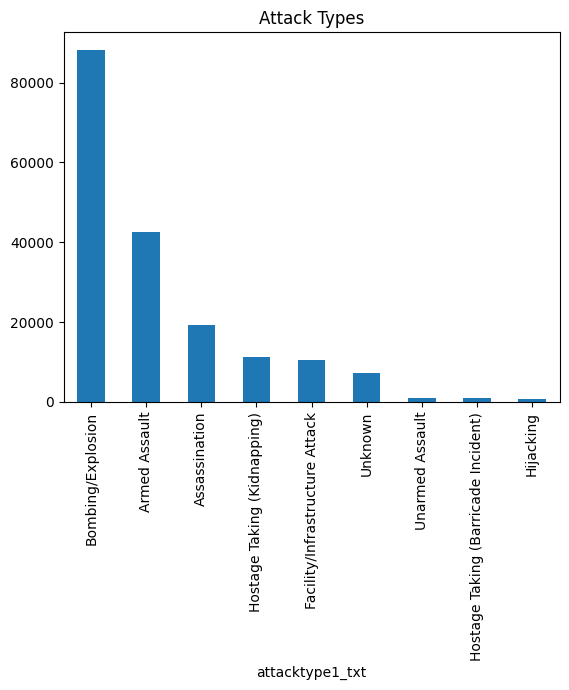

In [102]:
attacks = data['attacktype1_txt'].value_counts()
attacks.plot(kind='bar', title='Attack Types')
print(attacks)

weaptype1_txt
Explosives                                                                     92426
Firearms                                                                       58524
Unknown                                                                        15157
Incendiary                                                                     11135
Melee                                                                           3655
Chemical                                                                         321
Sabotage Equipment                                                               141
Vehicle (not to include vehicle-borne explosives, i.e., car or truck bombs)      136
Other                                                                            114
Biological                                                                        35
Fake Weapons                                                                      33
Radiological                                       

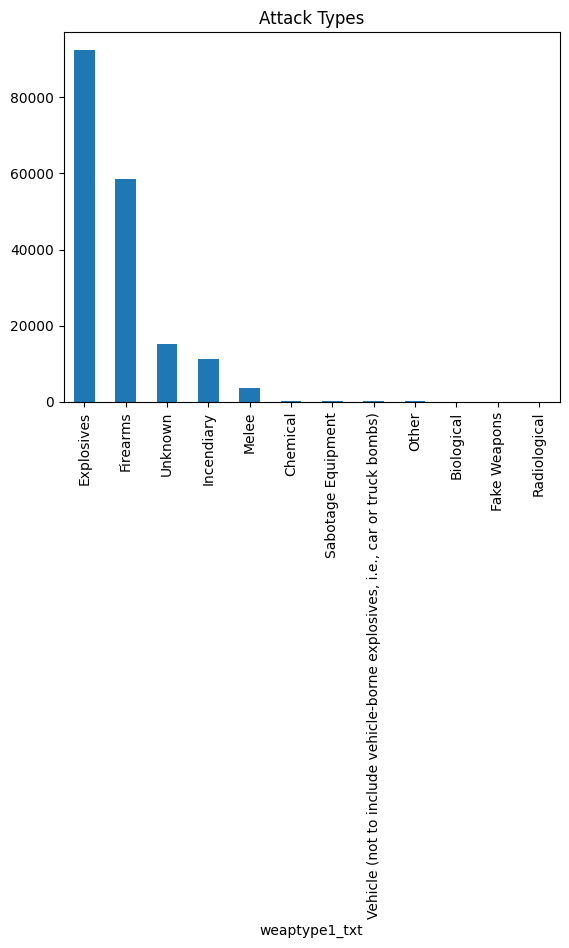

In [103]:
weapons = data['weaptype1_txt'].value_counts()
weapons.plot(kind='bar', title='Attack Types')
print(weapons)

gname
Taliban                                             7478
Islamic State of Iraq and the Levant (ISIL)         5613
Shining Path (SL)                                   4555
Farabundo Marti National Liberation Front (FMLN)    3351
Al-Shabaab                                          3288
New People's Army (NPA)                             2772
Irish Republican Army (IRA)                         2671
Revolutionary Armed Forces of Colombia (FARC)       2487
Boko Haram                                          2418
Kurdistan Workers' Party (PKK)                      2310
Basque Fatherland and Freedom (ETA)                 2024
Communist Party of India - Maoist (CPI-Maoist)      1878
Maoists                                             1630
Liberation Tigers of Tamil Eelam (LTTE)             1606
National Liberation Army of Colombia (ELN)          1561
Tehrik-i-Taliban Pakistan (TTP)                     1351
Palestinians                                        1125
Houthi extremists (Ansar 

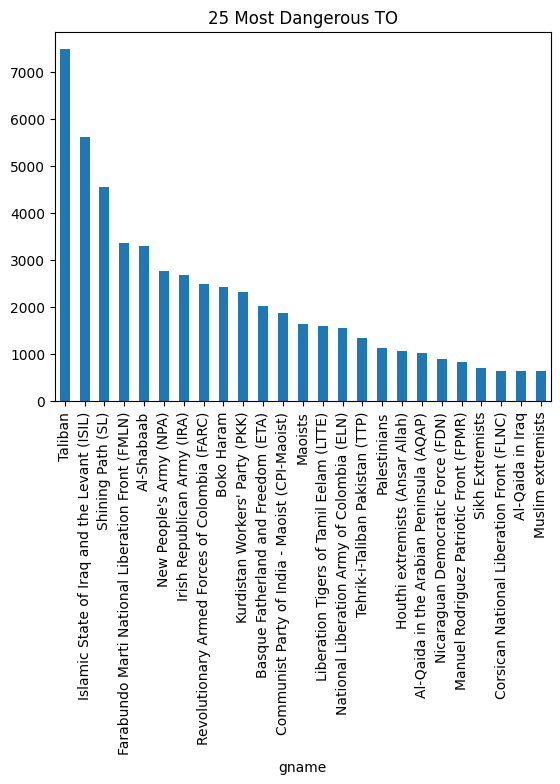

In [104]:
gangs = data['gname'].value_counts()
top_gangs=gangs[1:26]
top_gangs.plot(kind='bar', title='25 Most Dangerous TO')
print(top_gangs)

On previous three graphs we can see:
1. The most common attack type
2. THe most common weapon type
3. The top 25 dangerous gangs

As we can see, some of this groups, not only dangerous, but also have departments in other countries, that makes numbers even more terrible.

In next part I want to present their activity over years

In [114]:
filtered_data = data[data['gname'].isin(top_gangs.index)]
grouped_data = filtered_data.groupby(['iyear', 'gname'])['gname'].count().reset_index(name='count')
plt.figure(figsize=(10, 10))
fig = px.line(grouped_data,
              x='iyear',
              y='count',
              color='gname',
              title='Activities Over Years for 25 Most Dangerous Gangs')
fig.update_layout(xaxis_title='Year', yaxis_title='Number of Attacks')
fig.show()

<Figure size 1000x1000 with 0 Axes>

In the light of world wide protests that occure today, I want to present analyse of israel attacks versus palestinian attacks vs muslim extremists attacks.


List of Israel gang attacks /n gname
Israeli settlers              52
Israeli extremists            35
Israeli Terrorist Group        4
Save Our Israel Land           3
Black Hebrew Israelites        3
Anti-Israeli extremists        2
Arab-Israeli extremists        2
Israel Militant                1
Agudat Israel Party            1
Bedouin Israeli extremists     1
Name: count, dtype: int64 

List of palestinians attacks /n                Group  Count
0       Palestinians   1806
1  Muslim extremists    792
2       Israel gangs    104 



<Axes: title={'center': 'Comparison of Groups'}, xlabel='Group'>

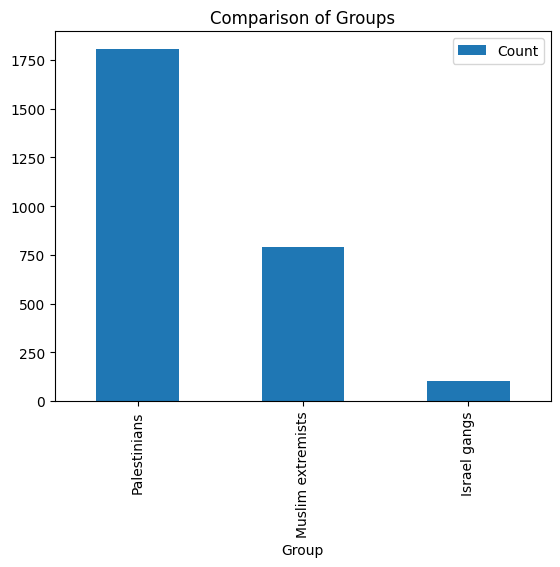

In [140]:
palestinians = data[data['gname'].str.contains('Palestinian')]['gname'].count()
muslim_extremists = data[data['gname'].str.contains('Muslim extremists')]['gname'].count()
israel_gangs = data[data['gname'].str.contains('Israel')]['gname'].value_counts()
israel_gangs_count = data[data['gname'].str.contains('Israel')]['gname'].count()
comp_data = pd.DataFrame({
    'Group': ['Palestinians', 'Muslim extremists', 'Israel gangs'],
    'Count': [palestinians, muslim_extremists, israel_gangs_count]
})
print(f'List of Israel gang attacks /n {israel_gangs} \n')
print(f'List of palestinians attacks /n {comp_data} \n')
comp_data.plot(kind='bar', x='Group', y='Count', title='Comparison of Groups')

We can see on a plot how low percentage of all Israel gangs attacks comparing to Palestinians or Muslim Extremists attacks

# Lets also analyse the most dangerous regions

In [143]:
country_counts = data['country_txt'].value_counts().reset_index()
country_counts.columns = ['country', 'count']
fig = px.choropleth(country_counts,
                    locations='country',
                    locationmode='country names',
                    color='count',
                    hover_name='country',
                    color_continuous_scale='Viridis',
                    title='Occurrences by Country')
fig.show()